# Question 5: Stars Classification

Building logistic regression to predict the spectral class of a star. Using temperature, luminosity, radius, and absolute magnitude as input X.

In [17]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, label_binarize

warnings.filterwarnings("ignore")

url = "https://github.com/YBIFoundation/Dataset/raw/main/Stars.csv"
df = pd.read_csv(url)

features = ["Temperature (K)", "Luminosity (L/Lo)",
            "Radius (R/Ro)", "Absolute magnitude (Mv)"]
X = df[features]
y_7 = df["Spectral Class"]

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (240, 8)


,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Star type,Star category,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,0,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,0,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,0,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,0,Brown Dwarf,Red,M


In [18]:
print("Summary of the four input features:")
display(X.describe().T)

print("Number of stars in each spectral class:")
display(y_7.value_counts())

Summary of the four input features:


,count,mean,std,min,25%,50%,75%,max
Temperature (K),240.0,10497.462500,9552.425037,1939.00000,3344.250000,5776.0000,15055.5000,40000.00
Luminosity (L/Lo),240.0,107188.361635,179432.244940,0.00008,0.000865,0.0705,198050.0000,849420.00
Radius (R/Ro),240.0,237.157781,517.155763,0.00840,0.102750,0.7625,42.7500,1948.50
Absolute magnitude (Mv),240.0,4.382396,10.532512,-11.92000,-6.232500,8.3130,13.6975,20.06


Number of stars in each spectral class:


Spectral Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1
Name: count, dtype: int64

## Evaluation

Conducting stratified cross-validation. Each star is predicted when it is in a validation fold.

Its performance will be evaluated by:

- **Accuracy:** the percentage of all predictions that are correct.
- **Precision:** out of the stars predicted as a class, how many actually belong to it.
- **Recall:** out of the stars that belong to a class, how many the model finds.
- **F1 score:** a balance between precision and recall.
- **Confusion matrix:** shows which classes the model mixes up.
- **ROC curve:** compares the true-positive and false-positive rates at different probability thresholds.
- **AUC:** summarizes the ROC curve. A value near 1 is good.


In [19]:
def run_experiment(X, y, folds, title):
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced")
    )
    cv = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

    # Predictions for every observation from its validation fold
    y_pred = cross_val_predict(model, X, y, cv=cv)
    y_prob = cross_val_predict(model, X, y, cv=cv, method="predict_proba")
    classes = np.unique(y)

    print("Accuracy:", round(accuracy_score(y, y_pred), 4))
    print("Macro precision:", round(precision_score(y, y_pred, average="macro", zero_division=0), 4))
    print("Macro recall:", round(recall_score(y, y_pred, average="macro", zero_division=0), 4))
    print("Macro F1:", round(f1_score(y, y_pred, average="macro", zero_division=0), 4))
    print("\nPer-class results:\n", classification_report(y, y_pred, zero_division=0))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ConfusionMatrixDisplay(
        confusion_matrix(y, y_pred, labels=classes), display_labels=classes
    ).plot(ax=axes[0], cmap="Blues", colorbar=False)
    axes[0].set_title("Confusion matrix")

    y_binary = label_binarize(y, classes=classes)
    for i, label in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_binary[:, i], y_prob[:, i])
        auc = roc_auc_score(y_binary[:, i], y_prob[:, i])
        axes[1].plot(fpr, tpr, label=f"{label}: {auc:.2f}")
    macro_auc = roc_auc_score(y_binary, y_prob, average="macro")
    axes[1].plot([0, 1], [0, 1], "k--")
    axes[1].set_xlabel("False-positive rate")
    axes[1].set_ylabel("True-positive rate")
    axes[1].set_title(f"One-vs-rest ROC (macro AUC = {macro_auc:.3f})")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    # Fit all data only to inspect coefficients; 
    model.fit(X, y)
    coefficients = pd.DataFrame(
        model.named_steps["logisticregression"].coef_,
        index=model.named_steps["logisticregression"].classes_,
        columns=features
    )
    display(coefficients.round(3))
    return coefficients

## 5.1 Predicting seven classes

I pick **5-fold cross-validation** because with 240 stars, each validation fold has about 48 stars, which is reasonable for small dataset.

The model gets an accuracy of **0.683** and a macro F1 score of **0.483**. It performs well on O, B, and M, but it has difficulty with F, G, and K. The confusion matrix makes these errors more obvious. The macro ROC AUC is about **0.781**, so the probability scores still separate many classes reasonably.

Accuracy: 0.6833
Macro precision: 0.5111
Macro recall: 0.4731
Macro F1: 0.4827

Per-class results:
               precision    recall  f1-score   support

           A       0.60      0.47      0.53        19
           B       0.80      0.70      0.74        46
           F       0.37      0.41      0.39        17
           G       0.00      0.00      0.00         1
           K       0.04      0.17      0.06         6
           M       0.96      0.74      0.84       111
           O       0.80      0.82      0.81        40

    accuracy                           0.68       240
   macro avg       0.51      0.47      0.48       240
weighted avg       0.81      0.68      0.74       240



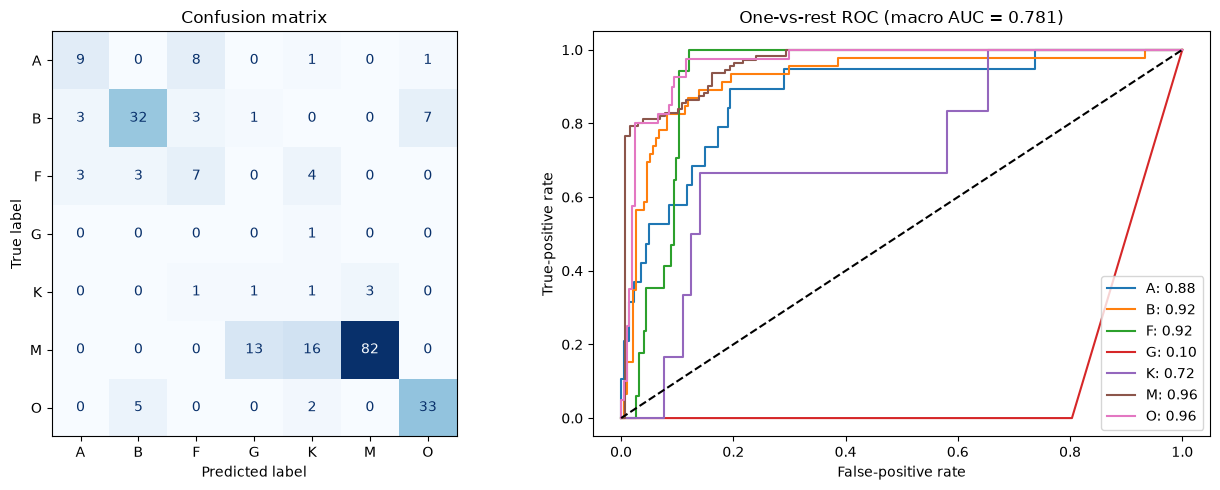

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv)
A,0.927,0.092,-0.376,0.081
B,3.171,0.122,-0.122,0.550
F,0.259,-0.818,-0.665,0.622
G,0.451,-0.972,1.992,-0.578
K,-3.217,0.391,-0.258,-0.120
M,-4.509,0.031,0.721,1.412
O,2.919,1.155,-1.292,-1.969


In [20]:
coef7 = run_experiment(X, y_7, folds=5, title="Experiment 5.1: Seven classes")

## 5.2 Predicting three grouped classes

Group the Spectral Class into 3 classe:

- **Hot Stars:** O, B, A
- **Intermediate Stars:** F, G
- **Cool Stars:** K, M

Picking **10-fold cross-validation** here. After grouping, the smallest class has 18 stars, so each validation fold can still contain at least one star from every group.
The performance for this experiment is better than experiment 1. The accuracy is **0.892**, the macro F1 score is **0.806**, and the macro ROC AUC is about **0.958**. Cool and Hot stars are classified very well. The Intermediate group has high recall but lower precision.

Spectral Class
Cool            117
Hot             105
Intermediate     18
Name: count, dtype: int64
Accuracy: 0.8917
Macro precision: 0.7932
Macro recall: 0.8877
Macro F1: 0.8062

Per-class results:
               precision    recall  f1-score   support

        Cool       0.99      0.97      0.98       117
         Hot       0.99      0.80      0.88       105
Intermediate       0.40      0.89      0.55        18

    accuracy                           0.89       240
   macro avg       0.79      0.89      0.81       240
weighted avg       0.95      0.89      0.91       240



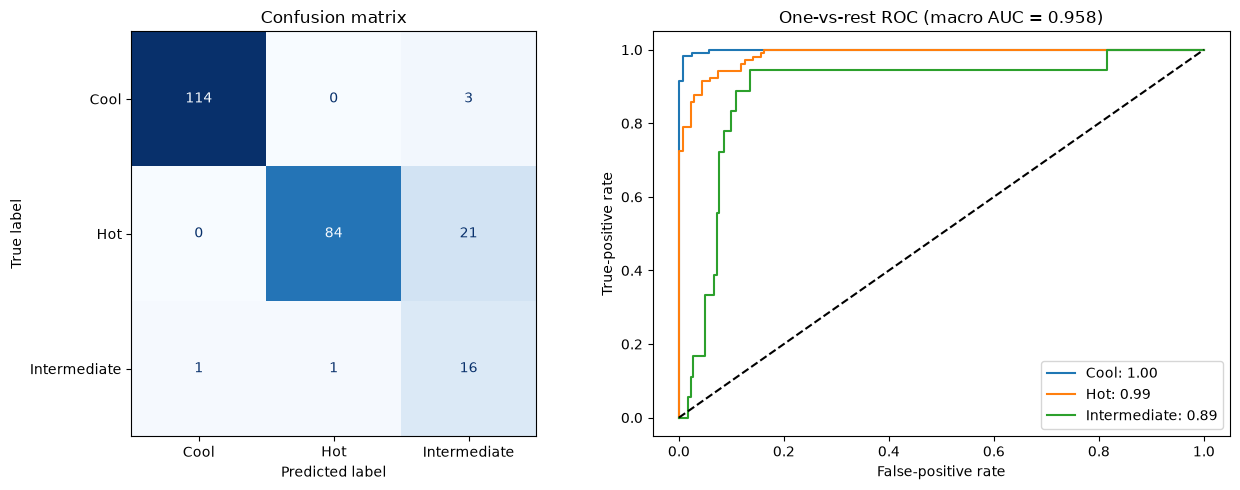

,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv)
Cool,-5.013,0.710,0.464,0.948
Hot,3.851,0.469,-0.600,-0.820
Intermediate,1.162,-1.179,0.136,-0.128


In [23]:
groups = {
    "O": "Hot", "B": "Hot", "A": "Hot",
    "F": "Intermediate", "G": "Intermediate",
    "K": "Cool", "M": "Cool"
}
y_3 = y_7.map(groups)

print(y_3.value_counts())
coef3 = run_experiment(X, y_3, folds=10, title="Experiment 5.2: Three classes")


##interpretation   the coefficients


For two classes $k$ and $l$, increasing feature $x_j$ by one standard deviation changes the log-odds of class $k$ compared with class $l$ by

$$
\Delta \log\left(\frac{P(Y=k\mid x)}{P(Y=l\mid x)}\right)
= \beta_{k,j}-\beta_{l,j}.
$$

The corresponding odds are multiplied by

$$
\exp\left(\beta_{k,j}-\beta_{l,j}\right).
$$

Therefore, a positive difference favors class $k$, and a negative difference favors class $l$, assuming the other features stay the same. I compare coefficient differences because this is a multiclass model, so one coefficient by itself does not describe a complete odds comparison.

In [25]:
# A concrete comparison: Hot versus Cool in experiment 5.2
hot_vs_cool = coef3.loc["Hot"] - coef3.loc["Cool"]
comparison = pd.DataFrame({
    "log-odds change": hot_vs_cool,
    "odds multiplier": np.exp(hot_vs_cool)
})
display(comparison.round(3))

# Compare the broad Hot-Cool direction across the two experiments.
seven_class_direction = (
    coef7.loc[["O", "B", "A"]].mean() - coef7.loc[["K", "M"]].mean()
)
display(pd.DataFrame({
    "7-class Hot average - Cool average": seven_class_direction,
    "3-class Hot - Cool": hot_vs_cool
}).round(3))

,log-odds change,odds multiplier
Temperature (K),8.864,7071.038
Luminosity (L/Lo),-0.241,0.786
Radius (R/Ro),-1.064,0.345
Absolute magnitude (Mv),-1.768,0.171


,7-class Hot average - Cool average,3-class Hot - Cool
Temperature (K),6.202,8.864
Luminosity (L/Lo),0.246,-0.241
Radius (R/Ro),-0.828,-1.064
Absolute magnitude (Mv),-1.092,-1.768
